**Preprocessing code for one image**

- You may need to install cv2 (`pip install opencv-python` or `pip install opencv-python-headless`).
- You may need to install imutils (`pip install imutils`).
- You may need to adjust the `image_path` variable to point to your image file. 

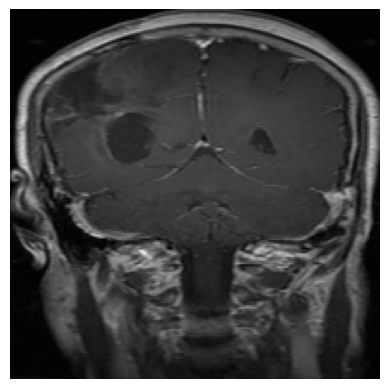

In [ ]:
import cv2
import os
import imutils
import matplotlib.pyplot as plt

def crop_img(img):
	"""
	Finds the extreme points on the image and crops the rectangular out of them
	"""
	gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
	gray = cv2.GaussianBlur(gray, (3, 3), 0)

	# threshold the image, then perform a series of erosions +
	# dilations to remove any small regions of noise
	thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
	thresh = cv2.erode(thresh, None, iterations=2)
	thresh = cv2.dilate(thresh, None, iterations=2)

	# find contours in thresholded image, then grab the largest one
	cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
	cnts = imutils.grab_contours(cnts)
	c = max(cnts, key=cv2.contourArea)

	# find the extreme points
	extLeft = tuple(c[c[:, :, 0].argmin()][0])
	extRight = tuple(c[c[:, :, 0].argmax()][0])
	extTop = tuple(c[c[:, :, 1].argmin()][0])
	extBot = tuple(c[c[:, :, 1].argmax()][0])
	ADD_PIXELS = 0
	new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()
	
	return new_img
	
image_path = "/Users/sarthakkale/Documents/TDA/Code/MRI/Training/glioma/Tr-gl_0041.jpg"

# Load and preprocess the image
IMG_SIZE = 200
image = cv2.imread(image_path)

cropped = crop_img(image)
resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB) #This step is necessary for displaying the image correctly in matplotlib (We will remove it when training for the whole folder)

# Show image in notebook
plt.imshow(resized_rgb)
plt.axis("off")
plt.show()


**To preprocess the whole glioma folder, we can run a for loop over all the images in the folder and save the preprocessed images in a new folder.**


In [ ]:
input_dir = "/Users/sarthakkale/Documents/TDA/Code/MRI/Training/glioma"
output_dir = "/Users/sarthakkale/Documents/TDA/Code/MRI/Training/glioma_preprocessed"
os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = 200
for filename in os.listdir(input_dir):
    if filename.lower().endswith(".jpg"):
        image_path = os.path.join(input_dir, filename)
        image = cv2.imread(image_path)
        cropped = crop_img(image)
        resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
        output_path = os.path.join(output_dir, filename)
        cv2.imwrite(output_path, resized)